In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor = "val_loss", mode = "min", patience = 5)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
EPOCHS = 20


In [3]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

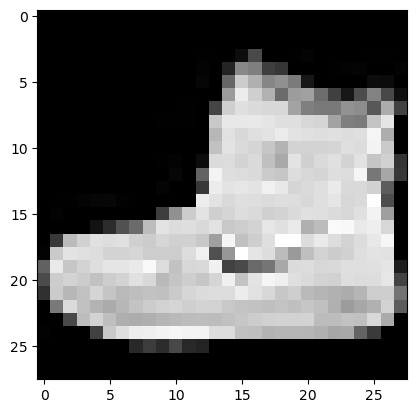

In [5]:
plt.imshow(x_train[0], cmap='gray')

In [6]:
x_train[0].shape

(28, 28)

In [7]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [8]:
pd.options.display.max_columns = None
pd.DataFrame(x_train[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,13,73,0,0,1,4,0,0,0,0,1,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,3,0,36,136,127,62,54,0,0,0,1,3,4,0,0,3
5,0,0,0,0,0,0,0,0,0,0,0,0,6,0,102,204,176,134,144,123,23,0,0,0,0,12,10,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,155,236,207,178,107,156,161,109,64,23,77,130,72,15
7,0,0,0,0,0,0,0,0,0,0,0,1,0,69,207,223,218,216,216,163,127,121,122,146,141,88,172,66
8,0,0,0,0,0,0,0,0,0,1,1,1,0,200,232,232,233,229,223,223,215,213,164,127,123,196,229,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,183,225,216,223,228,235,227,224,222,224,221,223,245,173,0


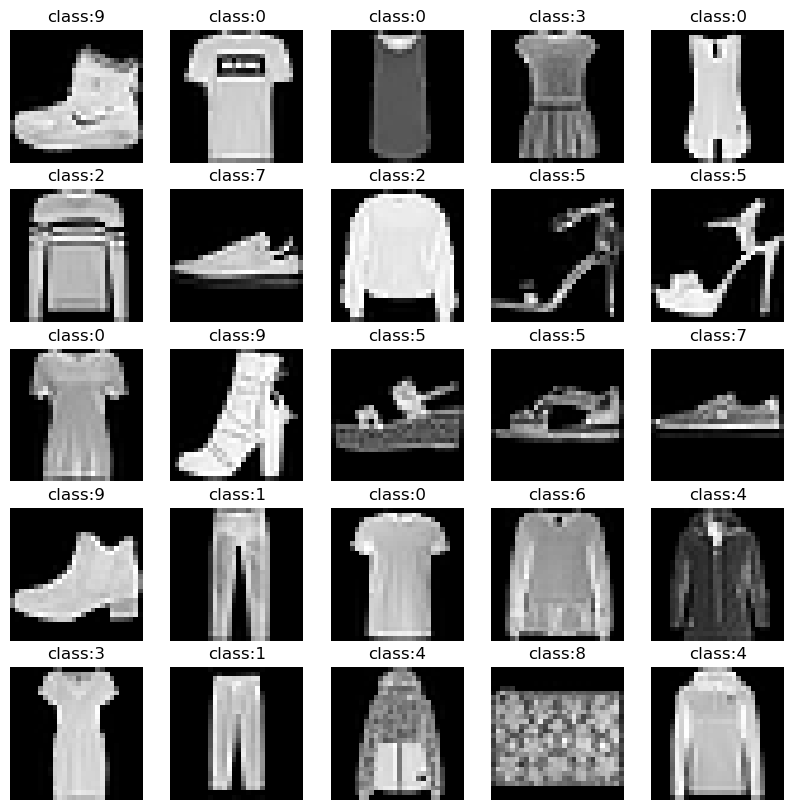

In [9]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
    plt.title("class:"+str(y_train[i]))

In [10]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [11]:
x_train.shape

(60000, 28, 28)

In [12]:
x_val = x_train[50000:]
y_val = y_train[50000:]

x_train = x_train[:50000]
y_train = y_train[:50000]

In [13]:
print(x_val.shape, x_train.shape)

(10000, 28, 28) (50000, 28, 28)


In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(32, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 32)                25120     
                                                                 
 dense_1 (Dense)             (None, 10)                330       
                                                                 
Total params: 25,450
Trainable params: 25,450
Non-trainable params: 0
_________________________________________________________________


In [15]:
history= model.fit(x_train, y_train, epochs = EPOCHS, validation_data=(x_val, y_val), callbacks = [es])
hist = pd.DataFrame(history.history)

Epoch 1/20
1563/1563 [==============================] - 6s 4ms/step - loss: 0.5754 - accuracy: 0.8023 - val_loss: 0.4497 - val_accuracy: 0.8426
Epoch 2/20
1563/1563 [==============================] - 5s 3ms/step - loss: 0.4277 - accuracy: 0.8509 - val_loss: 0.4091 - val_accuracy: 0.8552
Epoch 3/20
1563/1563 [==============================] - 5s 3ms/step - loss: 0.3898 - accuracy: 0.8626 - val_loss: 0.4028 - val_accuracy: 0.8597
Epoch 4/20
1563/1563 [==============================] - 5s 3ms/step - loss: 0.3719 - accuracy: 0.8674 - val_loss: 0.3793 - val_accuracy: 0.8697
Epoch 5/20
1563/1563 [==============================] - 5s 3ms/step - loss: 0.3531 - accuracy: 0.8735 - val_loss: 0.3794 - val_accuracy: 0.8675
Epoch 6/20
1563/1563 [==============================] - 5s 3ms/step - loss: 0.3414 - accuracy: 0.8780 - val_loss: 0.3651 - val_accuracy: 0.8712
Epoch 7/20
1563/1563 [==============================] - 5s 3ms/step - loss: 0.3301 - accuracy: 0.8803 - val_loss: 0.3664 - val_accuracy:

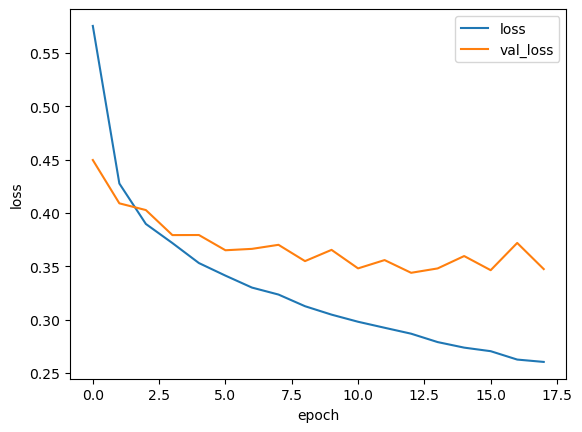

In [16]:
plt.plot(hist.loss, label = "loss")
plt.plot(hist.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [18]:
output = model.evaluate(x_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.3809 - accuracy: 0.8674


In [19]:
y_pred = model.predict(x_test)

313/313 [==============================] - 1s 2ms/step


[2.6097339e-06 1.9940950e-11 4.4096288e-07 6.1247533e-08 2.8824927e-06
 2.2907092e-03 1.2890758e-05 1.1193118e-02 5.7308648e-06 9.8649156e-01]


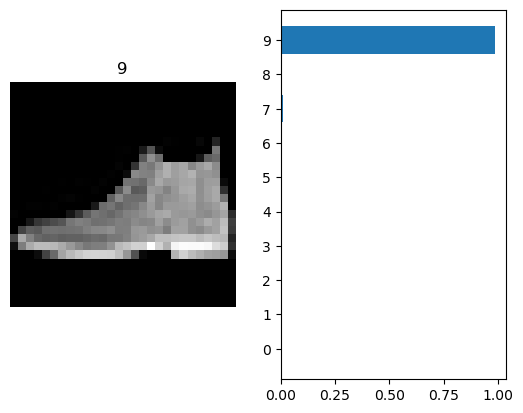

In [20]:
plt.subplot(1,2,1)
plt.imshow(x_test[0], cmap='gray')
plt.axis('off')
plt.title(y_test[0])

plt.subplot(1,2,2)
plt.barh(np.arange(10), y_pred[0])
plt.yticks(np.arange(10))
print(y_pred[0])

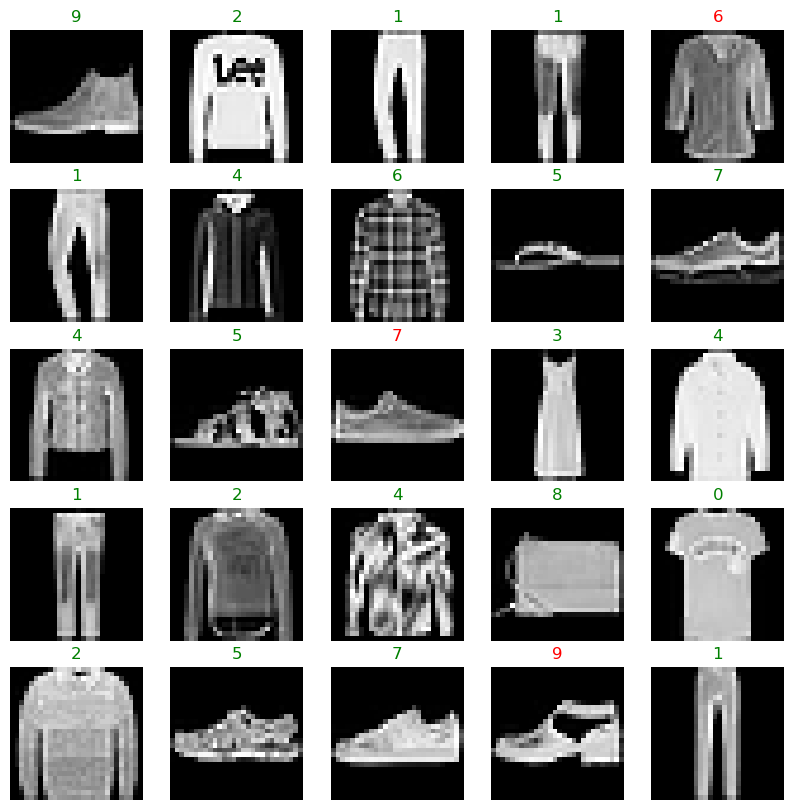

In [22]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')
    if np.argmax(y_pred[i]) == y_test[i]:
        plt.title(y_test[i], color = 'green')
    else:
        plt.title(y_test[i], color = 'red')